# Figure 5: Predictability of experimental and biological variables from functional GCL features

---
## Imports

In [1]:
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import itertools
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from datetime import date
import warnings
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import permutation_test_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

RESULTS_DIR = Path("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/all-GCL-analysis/results/")
assert RESULTS_DIR.is_dir()
SAVE_DIR = None  # Path("~/Desktop/allRGC_Plots").expanduser()
file_extension = "pdf"

FIGURE_HEIGHT = 6

plt.rcParams.update({'font.size': 14})


import os
import sys
sys.path.append(os.path.abspath('/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/all-GCL-manuscript/'))
from all_gcl_manuscript import style

os.makedirs('figures', exist_ok=True)
style.set_rc_params()
plt.rcParams["font.family"] = "DejaVu Sans"

---
## helper functions

In [26]:
def read_csv(filepath: str, label: str) -> list:
    res = []
    seeds_set = set()
    with open(filepath, "r") as f:
        for line in f:
            seed_, train_examples, test_examples, trace, _, _ = line.strip().split(",")
            seed = int(seed_)
            # "convert" to percentage
            trace = float(trace) * 100
            res.append((label, trace, int(train_examples) + int(test_examples)))
            if seed in seeds_set:
                print(f"Warning: Duplicate seed {seed} in {filepath}")
            seeds_set.add(seed)
    return res

def get_position(condition: str, num: int, offset: float = 0.0) -> float:
    condition_map = {c: i for i, c in enumerate(CONDITIONS_LIST_BINARY)}
    assert num == 0 or num == 1, f"Num: {num=}"
    pos = condition_map[condition] + num * 0.4 + offset
    return float(pos)


def get_label(p) -> str:
    if isinstance(p, str):
        label_str = p
    else:
        label_str = str(p.name)
    if "experimenter" in label_str:
        label_exp = label_str.replace("experimenter_random_forest_", "").replace("_features_chirp_8Hz_average_norm_preproc_bar.csv", "")
        # for k, v in MAP_NAMES.items():
        #     label_exp = label_exp.replace(k, v)
        return label_exp

    label_full = label_str.split("_")[0]

    if "sex" in label_full:
        return "Sex"
    elif "fieldId" in label_full:
        return "Field Id"
    elif "ventralDorsal" in label_full:
        return "Ventral Dorsal"
    elif "age" in label_full:
        return "Age"
    else:
        return label_full


def add_additional_info(df):
    label_encoder = LabelEncoder()
    encoded_experimenter = label_encoder.fit_transform(df['experimenter'].values)
    label_encoder = LabelEncoder()
    encoded_gender = label_encoder.fit_transform(df['animgender'].values)

    df['experimenter_id']=encoded_experimenter+1
    df['age_weeks'] = df['age']/7
    df['experimenter_id'] = df['experimenter_id'].replace({1: '1',2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7'})

    #group_ticks = ['1','2','3','4','5a','5b','5c','6','7','8a','8b','9','10','11','12','13','14','15','16','17','18',
    #              '19','20','21','22a','22b','23','24','25','26','27','28a','28b','29','30','31','31','31','31',
    #              '31','32a','32b','32c','33','34','35','36','37','38','39','40','41','42','43','44','45','46']

    #cell_type_map = {i + 1: name for i, name in enumerate(group_ticks)}
    #df['cell_type_name'] = df['group_id'].map(cell_type_map)
    df['gender_label'] = df['animgender'].map({'male': 0, 'female': 1})

    rgc_dac = np.zeros(df.shape[0])
    #rgc_dac[np.where(df['celltype']>43)[0]]=1
    rgc_dac[np.where(df['group_id']>32)[0]]=1
    df['rgc_dAC']=rgc_dac
    df['rgc_dAC'] = df['rgc_dAC'].replace({0: 'RGC', 1: 'dAC'})
    
    df = df.reset_index()

    return df


def balance_data(df):

    df_male = df[df['gender_label'] == 0]
    df_female = df[df['gender_label'] == 1]

    min_class_size = min(len(df_male), len(df_female))

    df_male_bal = resample(df_male, replace=False, n_samples=min_class_size, random_state=42)
    df_female_bal = resample(df_female, replace=False, n_samples=min_class_size, random_state=42)

    balanced_df = pd.concat([df_male_bal, df_female_bal]).sample(frac=1, random_state=42).reset_index(drop=True)

    return balanced_df


def balance_data_experimenter(df, exp_id_1, exp_id_2, seed):

    df_exp_1 = df[df['experimenter_id'] == exp_id_1]
    df_exp_2 = df[df['experimenter_id'] == exp_id_2]

    min_class_size = min(len(df_exp_1), len(df_exp_2))

    df_exp_1_bal = resample(df_exp_1, replace=False, n_samples=min_class_size, random_state=seed)
    df_exp_2_bal = resample(df_exp_2, replace=False, n_samples=min_class_size, random_state=seed)

    balanced_df = pd.concat([df_exp_1_bal, df_exp_2_bal]).sample(frac=1, random_state=seed).reset_index(drop=True)

    return balanced_df


def stratified_group_kfold_by_label(
    df, n_splits=5, label_col='label', group_col='date', features=None,
    seed_dataset=42, seed_rfc=42
):
    assert df[label_col].nunique() == 2, "Only works with binary classification"
    assert features is not None and len(features) > 0, "Provide a non-empty list of features"

    # ----- 1) Create a stable 0/1 mapping (pick the first class as 0, the second as 1) -----
    classes = sorted(df[label_col].dropna().unique(), key=lambda x: str(x))
    label_to01 = {classes[0]: 0, classes[1]: 1}
    df = df.copy()
    df['_y01'] = df[label_col].map(label_to01)

    # ----- 2) Stratify groups by the 0/1 label -----
    g0 = df[df['_y01'] == 0][group_col].dropna().unique()
    g1 = df[df['_y01'] == 1][group_col].dropna().unique()

    if len(g0) < n_splits or len(g1) < n_splits:
        raise ValueError(
            f"Not enough groups per class to make {n_splits} folds "
            f"(got {len(g0)} for class 0 and {len(g1)} for class 1)."
        )

    rng = np.random.RandomState(seed_dataset)
    rng.shuffle(g0); rng.shuffle(g1)
    g0_folds = np.array_split(g0, n_splits)
    g1_folds = np.array_split(g1, n_splits)

    all_results = []
    all_groups = np.concatenate([g0, g1])

    for fold in range(n_splits):
        test_groups  = np.concatenate([g0_folds[fold], g1_folds[fold]])
        train_groups = np.setdiff1d(all_groups, test_groups)

        train_df = df[df[group_col].isin(train_groups)]
        test_df  = df[df[group_col].isin(test_groups)]

        X_train, y_train = train_df[features], train_df['_y01']
        X_test,  y_test  = test_df[features],  test_df['_y01']

        clf = RandomForestClassifier(n_estimators=100, random_state=seed_rfc)
        clf.fit(X_train, y_train)

        y_pred  = clf.predict(X_test)
        proba_1_idx = list(clf.classes_).index(1)   # column for class 1
        y_proba = clf.predict_proba(X_test)[:, proba_1_idx]

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) == 2 else np.nan

        print(f"Fold {fold+1} | Test size: {len(test_df)} | Accuracy: {acc:.3f} | ROC AUC: {np.round(auc,3) if not np.isnan(auc) else 'NA'}")
        all_results.append({'fold': fold+1, 'test_accuracy': acc, 'test_roc_auc': auc})

    results_df = pd.DataFrame(all_results)
    print(f"\nMean Accuracy: {results_df.test_accuracy.mean():.3f} ± {results_df.test_accuracy.std():.3f}")
    print(f"Mean ROC AUC: {results_df.test_roc_auc.mean(skipna=True):.3f} ± {results_df.test_roc_auc.std(skipna=True):.3f}")
    return results_df
    
def pairwise_accuracy_matrix(
    df, all_experimenters, features,
    n_splits=5, n_seeds=10, base_seed=2024,
    label_col='experimenter_id', group_col='date'
):
    rng = np.random.RandomState(base_seed)
    seeds_balance = rng.randint(0, 2**31-1, size=n_seeds)
    seeds_dataset = rng.randint(0, 2**31-1, size=n_seeds)
    seeds_rfc     = rng.randint(0, 2**31-1, size=n_seeds)

    n = len(all_experimenters)
    acc_mean = np.full((n, n), np.nan)

    for i, exp_1 in enumerate(all_experimenters):
        for j in range(i+1, n):  # compute upper triangle once
            exp_2 = all_experimenters[j]
            accs = []

            for s in range(n_seeds):
                # balance the two experimenters
                balanced_df = balance_data_experimenter(
                    df=df, exp_id_1=exp_1, exp_id_2=exp_2, seed=int(seeds_balance[s])
                )
                if balanced_df[label_col].nunique() < 2:
                    continue

                cv_results = stratified_group_kfold_by_label(
                    df=balanced_df,
                    n_splits=n_splits,
                    label_col=label_col,
                    group_col=group_col,
                    features=features,
                    seed_dataset=int(seeds_dataset[s]),
                    seed_rfc=int(seeds_rfc[s]),
                )
                accs.append(cv_results['test_accuracy'].mean())

            a_mean = float(np.mean(accs)) if accs else np.nan
            acc_mean[i, j] = acc_mean[j, i] = a_mean  # mirror to keep symmetry

        acc_mean[i, i] = np.nan  # diagonal meaningless for pairwise

    idx = pd.Index(all_experimenters, name='exp_1')
    cols = pd.Index(all_experimenters, name='exp_2')
    return pd.DataFrame(acc_mean, index=idx, columns=cols)

---
## Load and quality filter dataset

In [118]:
from all_gcl_manuscript.utils import restore_numpy_arrays

dataset_path = "/gpfs01/euler/data/Resources/All-GCL/database/"
all_gcl_df = pd.read_parquet(os.path.join(dataset_path, "all_GCL_table.parquet"))
all_gcl_df = restore_numpy_arrays(all_gcl_df)

Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: srf


In [119]:
from all_gcl_manuscript.dataframe import filter_df

all_gcl_df = filter_df(
    df=all_gcl_df,
    condition_filter=False,
    quality_filter=True,
    location_filter=False,
    genline_filter=False,
    rf_quality_filter=False,
    verbose=True    
)

Filtering quality. Removing 38% of the data.


In [120]:
label_encoder = LabelEncoder()
encoded_experimenter = label_encoder.fit_transform(all_gcl_df['experimenter'].values)

label_encoder = LabelEncoder()
encoded_gender = label_encoder.fit_transform(all_gcl_df['animgender'].values)

all_gcl_df['experimenter_id']=encoded_experimenter+1
all_gcl_df['experimenter_id'] = all_gcl_df['experimenter_id'].replace({1: '1',2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7'})
all_gcl_df['age'] = all_gcl_df['age'].astype(int)
all_gcl_df['age_weeks'] = all_gcl_df['age'] / 7

# extract mean traces for plotting
chirp_responses = np.stack(all_gcl_df['preproc_chirp'])
mb_responses = np.stack(all_gcl_df['preproc_bar'])

In [122]:
seed_rfc = [42,489,3048,4,838,598,309,10,456,2837]
seed_balance = [394,1947,5867,2828,1010,3,123,66666,90909,52]
seed_dataset_group = [44949,121,5423,54645,834,3,63,22,357,192847]

---
## Panel A: load results from .csv file

In [128]:
MAP_NAMES = {
    "Cai": "Exp 1",
    "Dyszkant": "Exp 2",
    "Gonschorek": "Exp 3",
    "Szatko": "Exp 4",
    "Biggest": "Biggest",
}
ALL_EXPERIMENTERS = sorted(MAP_NAMES.keys())

all_files = [
    RESULTS_DIR / x for x in os.listdir(RESULTS_DIR) 
    if "celltype_scores" not in x and
    "features_chirp_8Hz_average_norm_preproc_bar" in x and
    "supergroup" not in x
    and (RESULTS_DIR / x).is_file()
]
all_results = {
    str(x.name): read_csv(x, label=get_label(x)) for x in all_files
}
biggest_exp_per_condition: dict[str, str] = {}
# find best experimenter for each conditon
conditions = {x.split("_")[0] for x in all_results.keys() if "random_forest_features" in x}
for cond in conditions:
    results_cond = [x for x in all_results.keys() if cond in x and "random_forest_features" not in x]
    most_test_examples = -1
    for fn in results_cond:
        test_ex = all_results[fn][0][2]
        if test_ex > most_test_examples:
            most_test_examples = test_ex
            exp = fn.split("random_forest_")[1].split("_")[0]
            biggest_exp_per_condition[cond] = exp
            all_results[f"{cond}_random_forest_Biggest_features_chirp_8Hz_average_norm_preproc_bar.csv"] = all_results[fn]
print(biggest_exp_per_condition)

# combine results to dicts
experimenter_results = {x: y for x, y in all_results.items() if "experimenter" in str(x)}
setup_results = {x: y for x, y in all_results.items() if "setup" in str(x)}
binary_results = {x: y for x, y in all_results.items() if "experimenter" not in str(x) and "setup" not in str(x)}
joint_results = binary_results | setup_results 

{'sex': 'Dyszkant', 'ventralDorsalBinary': 'Cai', 'setupid': 'Cai', 'fieldIdBinary-0-2': 'Cai', 'ageBinary': 'Gonschorek'}


---
## Panel B: Leave-one-out accuracy

In [132]:
def balance_data(df, seed):

    df_young = df[df['age_id'] == 'young']
    df_old = df[df['age_id'] == 'old']

    min_class_size = min(len(df_young), len(df_old))

    df_young_bal = resample(df_young, replace=False, n_samples=min_class_size, random_state=seed)
    df_old_bal = resample(df_old, replace=False, n_samples=min_class_size, random_state=seed)

    balanced_df = pd.concat([df_young, df_old]).sample(frac=1, random_state=seed).reset_index(drop=True)

    return balanced_df

def age_df(df):
    age = df['age_weeks']

    # age_id: <=10 → young, 10<age<15 → middle, >=15 → old
    df['age_id'] = np.select(
        [age.le(10), age.ge(15)],
        ['young', 'old'],
        default='middle'
    )
    
    df.loc[age.isna(), 'age_id'] = pd.NA
    
    df['age_id'] = pd.Categorical(
        df['age_id'],
        categories=['young', 'middle', 'old'],
    )
    
    df_young_old = df[df['age_id'].isin(['young', 'old'])].copy()
    df_young_old['age_id'] = df['age_id'].cat.remove_unused_categories()

    return df_young_old



def loeo_experimenter_balanced(df, features, label_col='age_id', exp_col='experimenter_id',
                               seed=42, balance_train=False, balance_test=True):
    classes = sorted(df[label_col].dropna().unique(), key=lambda x: str(x))
    map01 = {classes[0]:0, classes[1]:1}
    rng = np.random.RandomState(seed)

    rows = []
    for held in sorted(df[exp_col].dropna().astype(str).unique(), key=str):
        train = df[df[exp_col].astype(str) != held].copy()
        test  = df[df[exp_col].astype(str) == held].copy()

        # balance helper by age within a frame
        def bal(frame):
            a0 = frame[frame[label_col]==classes[0]]
            a1 = frame[frame[label_col]==classes[1]]
            m = min(len(a0), len(a1))
            if m == 0: return None
            b0 = resample(a0, replace=False, n_samples=m, random_state=rng)
            b1 = resample(a1, replace=False, n_samples=m, random_state=rng)
            return pd.concat([b0,b1]).sample(frac=1, random_state=seed)

        if balance_train:
            train_b = bal(train)
            if train_b is None:
                print(f"Skipping {held}: train has single class.")
                continue
            train = train_b

        if balance_test:
            test_b = bal(test)
            if test_b is None:
                print(f"Skipping {held}: test has single class (cannot eval).")
                continue
            test = test_b

        Xtr = train[features].values
        ytr = train[label_col].map(map01).values
        Xte = test[features].values
        yte = test[label_col].map(map01).values

        clf = RandomForestClassifier(n_estimators=300, random_state=seed)
        clf.fit(Xtr, ytr)

        proba = clf.predict_proba(Xte)[:, list(clf.classes_).index(1)]
        pred  = (proba >= 0.5).astype(int)
        acc = accuracy_score(yte, pred)
        auc = roc_auc_score(yte, proba) if len(np.unique(yte)) == 2 else np.nan

        print(f"Held out {held} | n_test={len(test):5d} | acc={acc:.3f} | auc={auc:.3f}")
        rows.append({'held_out_experimenter': held, 'n_test': len(test), 'accuracy': acc, 'roc_auc': auc})

    out = pd.DataFrame(rows).set_index('held_out_experimenter')
    return out

In [133]:
bar_names = [f'bar_{i+1}' for i in range(32)]
chirp_names = [f'chirp_{i+1}' for i in range(249)]

bar_df_full = pd.DataFrame(mb_responses, columns=bar_names)
chirp_df_full = pd.DataFrame(chirp_responses, columns=chirp_names)

setup_filt_df = all_gcl_df[all_gcl_df['setupid'].isin(['1'])]
setup_filt_df['setupid'].unique()

df_rfc_traces = pd.concat([setup_filt_df.reset_index(drop=True), bar_df_full, chirp_df_full], axis=1)
traces = bar_names + chirp_names

In [417]:
df_rfc_traces = df_rfc_traces[df_rfc_traces['experimenter']!='Franke']
df_rfc_traces = df_rfc_traces[df_rfc_traces['experimenter'].notna()]
all_experimenter_ids = df_rfc_traces['experimenter_id'].unique()
df_rfc_traces['experimenter_id'] = df_rfc_traces['experimenter_id'].astype(str)

In [134]:
df_rfc_traces = df_rfc_traces[df_rfc_traces['experimenter'].notna()]
features = bar_feature_names + chirp_feature_names
all_experimenters = np.sort(df_rfc_traces['experimenter_id'].unique().astype(str))
df_rfc_traces['experimenter_id'] = df_rfc_traces['experimenter_id'].astype(str)

### Age

In [146]:
df_young_old = age_df(df_rfc_traces)
balanced_df = balance_data(df_young_old, 42)

In [147]:
df_young_old_traces = age_df(df_rfc_traces)

In [148]:
loeo_df_age = loeo_experimenter_balanced(df=df_young_old_traces, 
                                         features=traces, 
                                         label_col='age_id', 
                                         exp_col='experimenter_id',
                                         balance_train=True, 
                                         balance_test=True)

Skipping 1: test has single class (cannot eval).
Held out 2 | n_test= 3106 | acc=0.502 | auc=0.503
Held out 3 | n_test= 2676 | acc=0.480 | auc=0.469
Held out 4 | n_test= 3464 | acc=0.470 | auc=0.465
Held out 6 | n_test= 8518 | acc=0.483 | auc=0.477
Held out 7 | n_test=  670 | acc=0.467 | auc=0.460
Skipping 8: test has single class (cannot eval).


### Animal's sex

In [149]:
loeo_df_sex = loeo_experimenter_balanced(df=df_rfc_traces, 
                                         features=traces, 
                                         label_col='animgender', 
                                         exp_col='experimenter_id',
                                         balance_train=True, 
                                         balance_test=True)

Held out 1 | n_test= 1490 | acc=0.538 | auc=0.565
Held out 2 | n_test= 4764 | acc=0.513 | auc=0.516
Held out 3 | n_test= 2232 | acc=0.546 | auc=0.551
Held out 4 | n_test= 6182 | acc=0.507 | auc=0.509
Held out 6 | n_test= 8418 | acc=0.505 | auc=0.513
Held out 7 | n_test= 1182 | acc=0.492 | auc=0.488
Held out 8 | n_test= 2692 | acc=0.499 | auc=0.508


### Retinal location

In [150]:
df = df_rfc_traces.copy()
vd = df['ventral_dorsal_pos_um']

vals = np.where(vd >= 250, 0, np.where(vd <= 250, 1, pd.NA))
df['location_binary'] = pd.Series(vals, index=df.index, dtype='Int8')

df_filtered = df[df['location_binary'].notna()].copy()

df = df_rfc_traces.copy()
vd = df['ventral_dorsal_pos_um']

vals = np.where(vd > 250, 0, np.where(vd < 250, 1, pd.NA))
df['location_binary'] = pd.Series(vals, index=df.index, dtype='Int8')

df_filtered = df[df['location_binary'].notna()].copy()

In [151]:
loeo_df_loc = loeo_experimenter_balanced(df=df_filtered, 
                                         features=traces, 
                                         label_col='location_binary', 
                                         exp_col='experimenter_id',
                                         balance_train=True, 
                                         balance_test=True)

Held out 1 | n_test= 2162 | acc=0.508 | auc=0.510
Held out 2 | n_test= 6114 | acc=0.514 | auc=0.511
Held out 3 | n_test= 1286 | acc=0.461 | auc=0.451
Held out 4 | n_test= 5008 | acc=0.476 | auc=0.477
Held out 6 | n_test= 8588 | acc=0.509 | auc=0.512
Held out 7 | n_test=  408 | acc=0.485 | auc=0.471
Skipping 8: test has single class (cannot eval).


### Field ID

In [152]:
field_id_a = ['GCL0', 'GCL0a', 'RGC0']
field_id_b = ['GCL1', 'GCL1a', 'RGC1', 'GCL01']

df = df_rfc_traces.copy()

# Initialize as NA, then fill per group
df['field_id'] = pd.NA
df.loc[df['field'].isin(field_id_a), 'field_id'] = 'field_id_a'
df.loc[df['field'].isin(field_id_b), 'field_id'] = 'field_id_b'

# Keep only the assigned rows
df_field = df[df['field_id'].notna()].copy()

# (optional) make it categorical for tidy plotting/grouping
df_field['field_id'] = pd.Categorical(df_field['field_id'],
                                      categories=['field_id_a','field_id_b'],
                                      ordered=False)

In [153]:
loeo_df_field = loeo_experimenter_balanced(df=df_field, 
                                         features=traces, 
                                         label_col='field_id', 
                                         exp_col='experimenter_id',
                                         balance_train=True, 
                                         balance_test=True)

Held out 1 | n_test= 1592 | acc=0.464 | auc=0.435
Held out 2 | n_test= 3468 | acc=0.497 | auc=0.493
Skipping 3: test has single class (cannot eval).
Held out 4 | n_test= 3426 | acc=0.482 | auc=0.480
Held out 6 | n_test= 7540 | acc=0.489 | auc=0.481
Held out 7 | n_test= 1102 | acc=0.498 | auc=0.497
Skipping 8: test has single class (cannot eval).


In [154]:
def normalize_loeo(df):
    df = df.copy()
    if 'accuracy' not in df.columns:
        if len(df.columns) >= 3:
            df.columns = ['n_test', 'accuracy', 'roc_auc'][:len(df.columns)]
        elif len(df.columns) == 2:
            df.columns = ['n_test', 'accuracy']
        else:
            raise ValueError("LOEO df must have at least an accuracy column.")
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df.index = df.index.astype(str)
    return df

def df_to_results(df):
    acc = df['accuracy'].astype(float).to_numpy()
    if np.nanmedian(acc) <= 1.0:
        acc = acc * 100.0
    labs = df.index.to_numpy()
    n    = (df['n_test'].to_numpy() if 'n_test' in df.columns
            else np.full(len(df), np.nan))
    return [(lab, float(a), (int(x) if not np.isnan(x) else np.nan))
            for lab, a, x in zip(labs, acc, n)]

# prepare data (fill what you actually have)
joint_results_2 = {
    'sex'     : df_to_results(normalize_loeo(loeo_df_sex)),
    'field'   : df_to_results(normalize_loeo(loeo_df_field)),
    'location': df_to_results(normalize_loeo(loeo_df_loc.iloc[:-1])),
    'age'     : df_to_results(normalize_loeo(loeo_df_age)),
}

---
## Panel C: Experimenter vs. experimenter

In [123]:
bar_feats_file = '/gpfs01/euler/data/Resources/Classifier/data/bar_feats.npz'
chirp_feats_file = '/gpfs01/euler/data/Resources/Classifier/data/chirp_feats.npz'

with open(bar_feats_file, "rb") as f:
    features_bar = np.load(f)

with open(chirp_feats_file, "rb") as f:
    features_chirp = np.load(f)

In [124]:
bar_feature_names = [f'bar_{i+1}' for i in range(8)]
chirp_feature_names = [f'chirp_{i+1}' for i in range(20)]

bar_df = pd.DataFrame(np.dot(mb_responses, features_bar), columns=bar_feature_names)
chirp_df = pd.DataFrame(np.dot(chirp_responses, features_chirp), columns=chirp_feature_names)

setup_filt_df = all_gcl_df[all_gcl_df['setupid'].isin(['1'])]
setup_filt_df['setupid'].unique()

df_rfc = pd.concat([setup_filt_df.reset_index(drop=True), bar_df, chirp_df], axis=1)
features = bar_feature_names + chirp_feature_names
all_experimenters = (df_rfc['experimenter_id'].astype(str).dropna().unique())

In [125]:
df_rfc_filt = df_rfc_filt[df_rfc_filt['experimenter'].notna()]
features = bar_feature_names + chirp_feature_names
all_experimenters = np.sort(df_rfc_filt['experimenter_id'].unique().astype(str))
df_rfc_filt['experimenter_id'] = df_rfc_filt['experimenter_id'].astype(str)
acc_summary = np.zeros((len(all_experimenters),len(all_experimenters)))

In [126]:
acc_df = pairwise_accuracy_matrix(
    df=df_rfc_filt,
    all_experimenters=all_experimenters,  # ordered list you want on axes
    features=features,
    n_splits=5,
    n_seeds=1,
    base_seed=2024,
    label_col='experimenter_id',
    group_col='date'
)

Fold 1 | Test size: 1636 | Accuracy: 0.604 | ROC AUC: 0.662
Fold 2 | Test size: 1567 | Accuracy: 0.543 | ROC AUC: 0.706
Fold 3 | Test size: 826 | Accuracy: 0.640 | ROC AUC: 0.671
Fold 4 | Test size: 1207 | Accuracy: 0.571 | ROC AUC: 0.597
Fold 5 | Test size: 722 | Accuracy: 0.564 | ROC AUC: 0.59

Mean Accuracy: 0.584 ± 0.038
Mean ROC AUC: 0.645 ± 0.050
Fold 1 | Test size: 1471 | Accuracy: 0.578 | ROC AUC: 0.609
Fold 2 | Test size: 2069 | Accuracy: 0.620 | ROC AUC: 0.675
Fold 3 | Test size: 797 | Accuracy: 0.521 | ROC AUC: 0.484
Fold 4 | Test size: 1060 | Accuracy: 0.556 | ROC AUC: 0.584
Fold 5 | Test size: 561 | Accuracy: 0.533 | ROC AUC: 0.524

Mean Accuracy: 0.561 ± 0.039
Mean ROC AUC: 0.575 ± 0.074
Fold 1 | Test size: 1434 | Accuracy: 0.573 | ROC AUC: 0.626
Fold 2 | Test size: 1991 | Accuracy: 0.576 | ROC AUC: 0.659
Fold 3 | Test size: 520 | Accuracy: 0.569 | ROC AUC: 0.613
Fold 4 | Test size: 921 | Accuracy: 0.555 | ROC AUC: 0.575
Fold 5 | Test size: 1092 | Accuracy: 0.512 | ROC AU

---
## Plot final summary

CONDITIONS_LIST_BINARY=['setupid_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'sex_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'fieldIdBinary-0-2_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'ventralDorsalBinary_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'ageBinary_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv']


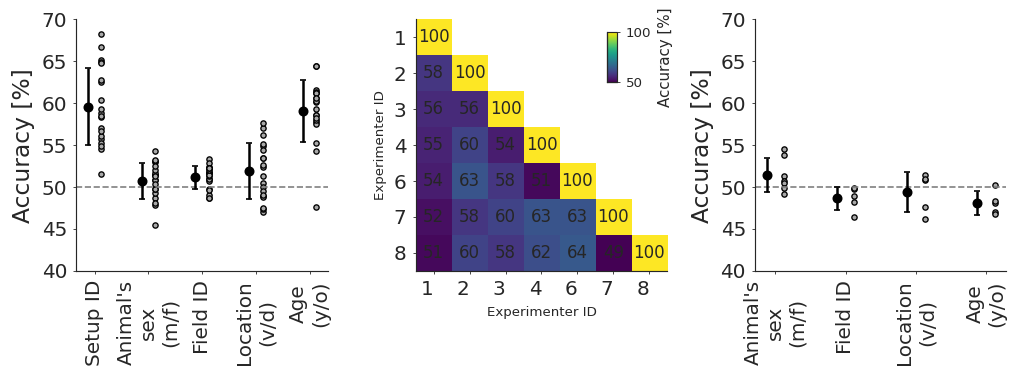

In [156]:
CONDITIONS_LIST_BINARY = sorted([x for x in joint_results.keys() if 
                                 all(exp not in x for exp in ALL_EXPERIMENTERS)])
# age, fieldId, sex, ventralDorsal
CONDITIONS_LIST_BINARY = [
    CONDITIONS_LIST_BINARY[2],  # setup id
    CONDITIONS_LIST_BINARY[3],  # sex
    CONDITIONS_LIST_BINARY[1],  # fieldId
    CONDITIONS_LIST_BINARY[4],  # ventralDorsal
    CONDITIONS_LIST_BINARY[0],  # age
]
print(f"{CONDITIONS_LIST_BINARY=}")


save = 0



# =================== helpers ===================

def get_position(condition: str, num: int, order, *, offset: float = 0.2, sep: float = 0.30) -> float:
    """Return x-position for a condition.
       order: list of condition names in desired left→right order
       num: 0 (left) or 1 (right) within a pair
       offset: global shift
       sep: distance between the two elements (0=overlap)
    """
    assert num in (0, 1), f"num must be 0 or 1, got {num}"
    base = order.index(condition)
    return float(base + num * sep + offset)

def plot_mean_err_and_scatter(
    ax, order, xlabels, joint_results, *,
    offset=0.05, sep=0.25, err_kind="std", marker="s", msize=6, capsize=4,
    y_label="Accuracy [%]", y_min=40, y_max=70
):
    """Plot mean ± error (std or sem) with an adjacent vertical stack of scatter points."""
    xticks, xticklabels = [], []
    n_examples_per_condition = defaultdict(list)

    for cond in order:
        results = joint_results.get(cond, [])
        if not results:
            continue

        scores = np.array([acc for (_, acc, _) in results], dtype=float)

        mean = float(np.mean(scores))
        if err_kind == "sem":
            err = float(np.std(scores, ddof=1) / np.sqrt(max(len(scores), 1))) if len(scores) > 1 else 0.0
        else:  # 'std'
            err = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0

        # positions: mean±err at num=0, scatter at num=1
        pos_mean   = get_position(cond, num=0, order=order, offset=offset, sep=sep)
        pos_points = get_position(cond, num=1, order=order, offset=offset, sep=sep)

        # mean ± error
        ax.errorbar(
            [pos_mean], [mean], yerr=[[err], [err]],
            fmt=marker, ms=msize, color="k", ecolor="k", elinewidth=1.5, capsize=capsize, zorder=3
        )

        # scatter aligned vertically
        ax.scatter(
            np.full_like(scores, pos_points, dtype=float),
            scores,
            color="darkgray", edgecolor="k", s=10.0, zorder=2
        )

        for _, _, n_ex in results:
            n_examples_per_condition[cond].append(n_ex)

        # tick centered between the pair
        xticks.append((pos_mean + pos_points) / 2.0)
        xticklabels.append(xlabels[order.index(cond)])

    # cosmetics
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_ylim(y_min, y_max)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=12, rotation=90)
    ax.tick_params(axis="both", which="major", labelsize=12)

    return n_examples_per_condition

# =================== styles ===================
BOX_WIDTH = 0.2
LINE_W    = 1
MED_W     = 1

# =================== figure ===================
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].set_box_aspect(1)
ax[2].set_box_aspect(1)

# ============================================================================
# Panel 1: mean ± std + adjacent scatter (from joint_results)
# ============================================================================
# e.g. CONDITIONS_LIST_BINARY = ['setup','sex','field','location','age']
xlabels_left = ["Setup ID", "Animal's\nsex\n(m/f)", 'Field ID', 'Location\n(v/d)', 'Age\n(y/o)']

_ = plot_mean_err_and_scatter(
    ax[0],
    order=CONDITIONS_LIST_BINARY,
    xlabels=xlabels_left,
    joint_results=joint_results,
    offset=0.05,
    sep=0.25,         # set the distance between mean marker and scatter
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)

# ============================================================================
# Panel 2: lower-triangle heatmap (acc_df) in percent, with integer labels
# ============================================================================
data = acc_df.values.astype(float) * 100
n = data.shape[0]
data = np.nan_to_num(data, nan=100)
data = data.astype(int)

mask_upper = np.triu(np.ones((n, n), dtype=bool), k=1)
mdata = np.ma.array(data, mask=mask_upper)

im = ax[1].imshow(mdata, vmin=50, vmax=100, aspect='equal', cmap='viridis')
im.cmap.set_bad(color='white')

for i_ in range(n):
    for j_ in range(n):
        if not mask_upper[i_, j_]:
            ax[1].text(j_, i_, f"{data[i_, j_]:.0f}", ha="center", va="center", fontsize=10)

ax[1].set_xticks(range(len(acc_df.columns)))
ax[1].set_yticks(range(len(acc_df.index)))
ax[1].set_xticklabels(acc_df.columns, rotation=0, ha='right')
ax[1].set_yticklabels(acc_df.index)
ax[1].set_ylabel('Experimenter ID')
ax[1].set_xlabel('Experimenter ID')

cax = inset_axes(ax[1], width="20%", height="20%", loc=5,
                 bbox_to_anchor=(0.6, 0.35, 0.2, 1), bbox_transform=ax[1].transAxes, borderpad=0)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Accuracy [%]", fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax[1].tick_params(axis="both", which="major", labelsize=12)

# ============================================================================
# Panel 3: mean ± std + adjacent scatter for experimenter-metadata (joint_results_2)
# ============================================================================
CONDITIONS_LIST_BINARY_2 = ['sex', 'field', 'location', 'age']
xlabels_right = ["Animal's\nsex\n(m/f)", "Field ID", "Location\n(v/d)", "Age\n(y/o)"]

_ = plot_mean_err_and_scatter(
    ax[2],
    order=CONDITIONS_LIST_BINARY_2,
    xlabels=xlabels_right,
    joint_results=joint_results_2,
    offset=0.05,
    sep=0.25,
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)

# ----------
sns.despine()
fig.subplots_adjust(wspace=0.35)
plt.show()

if save == 1:
    figname = 'metadata_prediction_v3'
    fig.patch.set_facecolor('white')
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_metadata/{}.png".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_metadata/{}.svg".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)

In [191]:
# =================== helpers ===================

def get_position(condition: str, num: int, order, *, offset: float = 0.2, sep: float = 0.30) -> float:
    """Return x-position for a condition.
       order: list of condition names in desired left→right order
       num: 0 (left) or 1 (right) within a pair
       offset: global shift
       sep: distance between the two elements (0=overlap)
    """
    assert num in (0, 1), f"num must be 0 or 1, got {num}"
    base = order.index(condition)
    return float(base + num * sep + offset)

def plot_mean_err_and_scatter(
    ax, order, xlabels, joint_results, *,
    offset=0.05, sep=0.25, err_kind="std", marker="s", msize=6, capsize=4,
    y_label="Accuracy [%]", y_min=40, y_max=70, level=50
):
    """Plot mean ± error (std or sem) with an adjacent vertical stack of scatter points."""
    xticks, xticklabels = [], []
    n_examples_per_condition = defaultdict(list)

    for cond in order:
        results = joint_results.get(cond, [])
        if not results:
            continue

        scores = np.array([acc for (_, acc, _) in results], dtype=float)

        mean = float(np.mean(scores))
        if err_kind == "sem":
            err = float(np.std(scores, ddof=1) / np.sqrt(max(len(scores), 1))) if len(scores) > 1 else 0.0
        else:  # 'std'
            err = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0

        # positions: mean±err at num=0, scatter at num=1
        pos_mean   = get_position(cond, num=0, order=order, offset=offset, sep=sep)
        pos_points = get_position(cond, num=1, order=order, offset=offset, sep=sep)

        # mean ± error
        ax.errorbar(
            [pos_mean], [mean], yerr=[[err], [err]],
            fmt=marker, ms=msize, color="k", ecolor="k", elinewidth=1.5, capsize=capsize, zorder=3
        )

        # scatter aligned vertically
        ax.scatter(
            np.full_like(scores, pos_points, dtype=float),
            scores,
            color="darkgray", edgecolor="k", s=10.0, zorder=2
        )

        for _, _, n_ex in results:
            n_examples_per_condition[cond].append(n_ex)

        # tick centered between the pair
        xticks.append((pos_mean + pos_points) / 2.0)
        xticklabels.append(xlabels[order.index(cond)])

    # cosmetics
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_ylim(y_min, y_max)
    ax.axhline(level, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=10, rotation=90)
    ax.tick_params(axis="both", which="major", labelsize=10)

    return n_examples_per_condition

CONDITIONS_LIST_BINARY=['ageBinary_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'fieldIdBinary-0-2_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'setupid_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'sex_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'ventralDorsalBinary_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv']


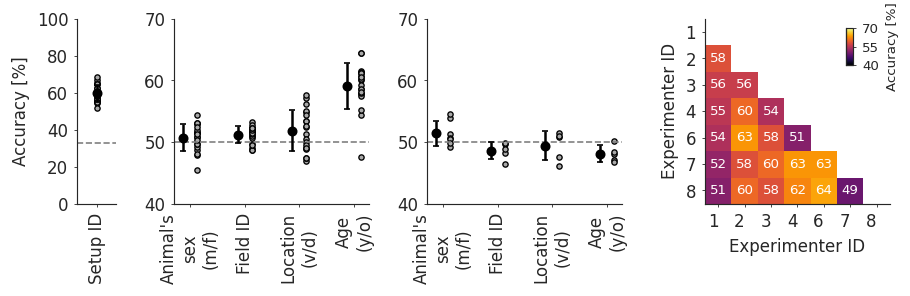

In [216]:
CONDITIONS_LIST_BINARY = sorted([x for x in joint_results.keys() if 
                                 all(exp not in x for exp in ALL_EXPERIMENTERS)])

print(f"{CONDITIONS_LIST_BINARY=}")


save = 1

# =================== styles ===================
BOX_WIDTH = 0.2
LINE_W    = 1
MED_W     = 1

# =================== figure ===================
fig, ax = plt.subplots(1, 4, figsize=(9, 2), gridspec_kw={'width_ratios': [0.2, 1., 1., 1.2]})
#ax[0].set_box_aspect(1)
#ax[1].set_box_aspect(1)
#ax[2].set_box_aspect(1)


# ============================================================================
# Panel 1: Setup ID only
# ============================================================================

# age, fieldId, sex, ventralDorsal
CONDITIONS_LIST_BINARY_setup = [
    CONDITIONS_LIST_BINARY[2]  # setup id
]

xlabels_left = ["Setup ID"]

_ = plot_mean_err_and_scatter(
    ax[0],
    order=CONDITIONS_LIST_BINARY_setup,
    xlabels=xlabels_left,
    joint_results=joint_results,
    offset=0.0,
    sep=0.,         # set the distance between mean marker and scatter
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=0, y_max=100, level=33
)


# ============================================================================
# Panel 1: mean ± std + adjacent scatter (from joint_results)
# ============================================================================
# e.g. CONDITIONS_LIST_BINARY = ['setup','sex','field','location','age']
# age, fieldId, sex, ventralDorsal
CONDITIONS_LIST_BINARY = [
    CONDITIONS_LIST_BINARY[3],  # sex
    CONDITIONS_LIST_BINARY[1],  # fieldId
    CONDITIONS_LIST_BINARY[4],  # ventralDorsal
    CONDITIONS_LIST_BINARY[0],  # age
]

xlabels_left = ["Setup ID", "Animal's\nsex\n(m/f)", 'Field ID', 'Location\n(v/d)', 'Age\n(y/o)']
xlabels_left = ["Animal's\nsex\n(m/f)", 'Field ID', 'Location\n(v/d)', 'Age\n(y/o)']

_ = plot_mean_err_and_scatter(
    ax[1],
    order=CONDITIONS_LIST_BINARY,
    xlabels=xlabels_left,
    joint_results=joint_results,
    offset=0.05,
    sep=0.25,         # set the distance between mean marker and scatter
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)


# ============================================================================
# Panel 3: mean ± std + adjacent scatter for experimenter-metadata (joint_results_2)
# ============================================================================
CONDITIONS_LIST_BINARY_2 = ['sex', 'field', 'location', 'age']
xlabels_right = ["Animal's\nsex\n(m/f)", "Field ID", "Location\n(v/d)", "Age\n(y/o)"]

_ = plot_mean_err_and_scatter(
    ax[2],
    order=CONDITIONS_LIST_BINARY_2,
    xlabels=xlabels_right,
    joint_results=joint_results_2,
    offset=0.05,
    sep=0.25,
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)


# ============================================================================
# Panel 4: lower-triangle heatmap (acc_df) in percent, with integer labels
# ============================================================================
data = acc_df.values.astype(float) * 100
n = data.shape[0]
data = np.nan_to_num(data, nan=100)
data = data.astype(int)

mask_upper = np.triu(np.ones((n, n), dtype=bool), k=1)
mask_upper = np.triu(np.ones((n, n), dtype=bool), k=0)

mdata = np.ma.array(data, mask=mask_upper)

im = ax[3].imshow(mdata, vmin=40, vmax=70, aspect='equal', cmap='inferno')
im.cmap.set_bad(color='white')

for i_ in range(n):
    for j_ in range(n):
        if not mask_upper[i_, j_]:
            ax[3].text(j_, i_, f"{data[i_, j_]:.0f}", ha="center", va="center", fontsize=8, color='white')

ax[3].set_xticks(range(len(acc_df.columns)))
ax[3].set_yticks(range(len(acc_df.index)))
ax[3].set_xticklabels(acc_df.columns, rotation=0, ha='right')
ax[3].set_yticklabels(acc_df.index)
ax[3].set_ylabel('Experimenter ID', fontsize=10)
ax[3].set_xlabel('Experimenter ID', fontsize=10)

cax = inset_axes(ax[3], width="20%", height="20%", loc=5,
                 bbox_to_anchor=(0.6, 0.35, 0.2, 1), bbox_transform=ax[3].transAxes, borderpad=0)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Accuracy [%]", fontsize=8)
cbar.set_ticks([40, 55, 70])
cbar.ax.tick_params(labelsize=8)
ax[3].tick_params(axis="both", which="major", labelsize=10)


ax[1].set_ylabel('')
ax[2].set_ylabel('')

# ----------
sns.despine()
fig.subplots_adjust(wspace=0.35)
plt.show()

if save == 1:
    figname = 'metadata_prediction_v4'
    fig.patch.set_facecolor('white')
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_5_metadata/{}.png".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_5_metadata/{}.svg".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)

# Plot final version

CONDITIONS_LIST_BINARY=['setupid_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'sex_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'fieldIdBinary-0-2_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'ventralDorsalBinary_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv', 'ageBinary_random_forest_features_chirp_8Hz_average_norm_preproc_bar.csv']


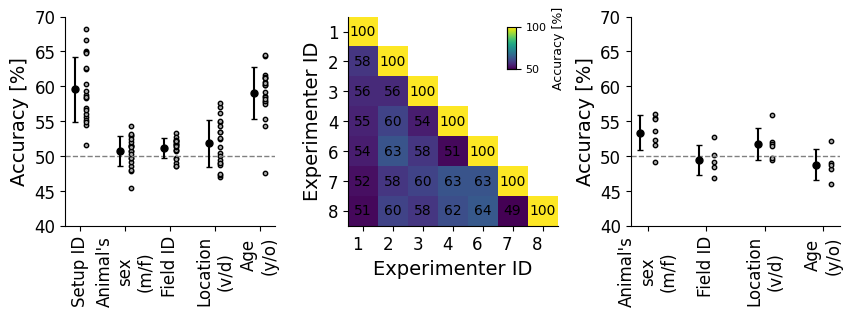

In [631]:
CONDITIONS_LIST_BINARY = sorted([x for x in joint_results.keys() if 
                                 all(exp not in x for exp in ALL_EXPERIMENTERS)])
# age, fieldId, sex, ventralDorsal
CONDITIONS_LIST_BINARY = [
    CONDITIONS_LIST_BINARY[2],  # setup id
    CONDITIONS_LIST_BINARY[3],  # sex
    CONDITIONS_LIST_BINARY[1],  # fieldId
    CONDITIONS_LIST_BINARY[4],  # ventralDorsal
    CONDITIONS_LIST_BINARY[0],  # age
]
print(f"{CONDITIONS_LIST_BINARY=}")


save = 0



# =================== helpers ===================

def get_position(condition: str, num: int, order, *, offset: float = 0.2, sep: float = 0.30) -> float:
    """Return x-position for a condition.
       order: list of condition names in desired left→right order
       num: 0 (left) or 1 (right) within a pair
       offset: global shift
       sep: distance between the two elements (0=overlap)
    """
    assert num in (0, 1), f"num must be 0 or 1, got {num}"
    base = order.index(condition)
    return float(base + num * sep + offset)

def plot_mean_err_and_scatter(
    ax, order, xlabels, joint_results, *,
    offset=0.05, sep=0.25, err_kind="std", marker="s", msize=6, capsize=4,
    y_label="Accuracy [%]", y_min=40, y_max=70
):
    """Plot mean ± error (std or sem) with an adjacent vertical stack of scatter points."""
    xticks, xticklabels = [], []
    n_examples_per_condition = defaultdict(list)

    for cond in order:
        results = joint_results.get(cond, [])
        if not results:
            continue

        scores = np.array([acc for (_, acc, _) in results], dtype=float)

        mean = float(np.mean(scores))
        if err_kind == "sem":
            err = float(np.std(scores, ddof=1) / np.sqrt(max(len(scores), 1))) if len(scores) > 1 else 0.0
        else:  # 'std'
            err = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0

        # positions: mean±err at num=0, scatter at num=1
        pos_mean   = get_position(cond, num=0, order=order, offset=offset, sep=sep)
        pos_points = get_position(cond, num=1, order=order, offset=offset, sep=sep)

        # mean ± error
        ax.errorbar(
            [pos_mean], [mean], yerr=[[err], [err]],
            fmt=marker, ms=msize, color="k", ecolor="k", elinewidth=1.5, capsize=capsize, zorder=3
        )

        # scatter aligned vertically
        ax.scatter(
            np.full_like(scores, pos_points, dtype=float),
            scores,
            color="darkgray", edgecolor="k", s=10.0, zorder=2
        )

        for _, _, n_ex in results:
            n_examples_per_condition[cond].append(n_ex)

        # tick centered between the pair
        xticks.append((pos_mean + pos_points) / 2.0)
        xticklabels.append(xlabels[order.index(cond)])

    # cosmetics
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_ylim(y_min, y_max)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=12, rotation=90)
    ax.tick_params(axis="both", which="major", labelsize=12)

    return n_examples_per_condition

# =================== styles ===================
BOX_WIDTH = 0.2
LINE_W    = 1
MED_W     = 1

# =================== figure ===================
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].set_box_aspect(1)
ax[2].set_box_aspect(1)

# ============================================================================
# Panel 1: mean ± std + adjacent scatter (from joint_results)
# ============================================================================
# e.g. CONDITIONS_LIST_BINARY = ['setup','sex','field','location','age']
xlabels_left = ["Setup ID", "Animal's\nsex\n(m/f)", 'Field ID', 'Location\n(v/d)', 'Age\n(y/o)']

_ = plot_mean_err_and_scatter(
    ax[0],
    order=CONDITIONS_LIST_BINARY,
    xlabels=xlabels_left,
    joint_results=joint_results,
    offset=0.05,
    sep=0.25,         # set the distance between mean marker and scatter
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)

# ============================================================================
# Panel 2: lower-triangle heatmap (acc_df) in percent, with integer labels
# ============================================================================
data = acc_df.values.astype(float) * 100
n = data.shape[0]
data = np.nan_to_num(data, nan=100)
data = data.astype(int)

mask_upper = np.triu(np.ones((n, n), dtype=bool), k=1)
mdata = np.ma.array(data, mask=mask_upper)

im = ax[1].imshow(mdata, vmin=50, vmax=100, aspect='equal', cmap='viridis')
im.cmap.set_bad(color='white')

for i_ in range(n):
    for j_ in range(n):
        if not mask_upper[i_, j_]:
            ax[1].text(j_, i_, f"{data[i_, j_]:.0f}", ha="center", va="center", fontsize=10)

ax[1].set_xticks(range(len(acc_df.columns)))
ax[1].set_yticks(range(len(acc_df.index)))
ax[1].set_xticklabels(acc_df.columns, rotation=0, ha='right')
ax[1].set_yticklabels(acc_df.index)
ax[1].set_ylabel('Experimenter ID')
ax[1].set_xlabel('Experimenter ID')

cax = inset_axes(ax[1], width="20%", height="20%", loc=5,
                 bbox_to_anchor=(0.6, 0.35, 0.2, 1), bbox_transform=ax[1].transAxes, borderpad=0)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Accuracy [%]", fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax[1].tick_params(axis="both", which="major", labelsize=12)

# ============================================================================
# Panel 3: mean ± std + adjacent scatter for experimenter-metadata (joint_results_2)
# ============================================================================
CONDITIONS_LIST_BINARY_2 = ['sex', 'field', 'location', 'age']
xlabels_right = ["Animal's\nsex\n(m/f)", "Field ID", "Location\n(v/d)", "Age\n(y/o)"]

_ = plot_mean_err_and_scatter(
    ax[2],
    order=CONDITIONS_LIST_BINARY_2,
    xlabels=xlabels_right,
    joint_results=joint_results_2,
    offset=0.05,
    sep=0.25,
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)

# ----------
sns.despine()
fig.subplots_adjust(wspace=0.35)
plt.show()

if save == 1:
    figname = 'metadata_prediction_v3'
    fig.patch.set_facecolor('white')
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_metadata/{}.png".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_metadata/{}.svg".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)

In [1]:
# add near your other imports
from matplotlib.patheffects import withStroke

CONDITIONS_LIST_BINARY = sorted([x for x in joint_results.keys() if 
                                 all(exp not in x for exp in ALL_EXPERIMENTERS)])
# age, fieldId, sex, ventralDorsal
CONDITIONS_LIST_BINARY = [
    CONDITIONS_LIST_BINARY[2],  # setup id
    CONDITIONS_LIST_BINARY[3],  # sex
    CONDITIONS_LIST_BINARY[1],  # fieldId
    CONDITIONS_LIST_BINARY[4],  # ventralDorsal
    CONDITIONS_LIST_BINARY[0],  # age
]
print(f"{CONDITIONS_LIST_BINARY=}")


save = 0



# =================== helpers ===================

def get_position(condition: str, num: int, order, *, offset: float = 0.2, sep: float = 0.30) -> float:
    """Return x-position for a condition.
       order: list of condition names in desired left→right order
       num: 0 (left) or 1 (right) within a pair
       offset: global shift
       sep: distance between the two elements (0=overlap)
    """
    assert num in (0, 1), f"num must be 0 or 1, got {num}"
    base = order.index(condition)
    return float(base + num * sep + offset)

def plot_mean_err_and_scatter(
    ax, order, xlabels, joint_results, *,
    offset=0.05, sep=0.25, err_kind="std", marker="s", msize=6, capsize=4,
    y_label="Accuracy [%]", y_min=40, y_max=70
):
    """Plot mean ± error (std or sem) with an adjacent vertical stack of scatter points."""
    xticks, xticklabels = [], []
    n_examples_per_condition = defaultdict(list)

    for cond in order:
        results = joint_results.get(cond, [])
        if not results:
            continue

        scores = np.array([acc for (_, acc, _) in results], dtype=float)

        mean = float(np.mean(scores))
        if err_kind == "sem":
            err = float(np.std(scores, ddof=1) / np.sqrt(max(len(scores), 1))) if len(scores) > 1 else 0.0
        else:  # 'std'
            err = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0

        # positions: mean±err at num=0, scatter at num=1
        pos_mean   = get_position(cond, num=0, order=order, offset=offset, sep=sep)
        pos_points = get_position(cond, num=1, order=order, offset=offset, sep=sep)

        # mean ± error
        ax.errorbar(
            [pos_mean], [mean], yerr=[[err], [err]],
            fmt=marker, ms=msize, color="k", ecolor="k", elinewidth=1.5, capsize=capsize, zorder=3
        )

        # scatter aligned vertically
        ax.scatter(
            np.full_like(scores, pos_points, dtype=float),
            scores,
            color="darkgray", edgecolor="k", s=10.0, zorder=2
        )

        for _, _, n_ex in results:
            n_examples_per_condition[cond].append(n_ex)

        # tick centered between the pair
        xticks.append((pos_mean + pos_points) / 2.0)
        xticklabels.append(xlabels[order.index(cond)])

    # cosmetics
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_ylim(y_min, y_max)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=12, rotation=90)
    ax.tick_params(axis="both", which="major", labelsize=12)

    return n_examples_per_condition

# =================== styles ===================
BOX_WIDTH = 0.2
LINE_W    = 1
MED_W     = 1

# =================== figure ===================
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].set_box_aspect(1)
ax[2].set_box_aspect(1)

# ============================================================================
# Panel 1: mean ± std + adjacent scatter (from joint_results)
# ============================================================================
# e.g. CONDITIONS_LIST_BINARY = ['setup','sex','field','location','age']
xlabels_left = ["Setup ID", "Animal's\nsex\n(m/f)", 'Field ID', 'Location\n(v/d)', 'Age\n(y/o)']

_ = plot_mean_err_and_scatter(
    ax[0],
    order=CONDITIONS_LIST_BINARY,
    xlabels=xlabels_left,
    joint_results=joint_results,
    offset=0.05,
    sep=0.25,         # set the distance between mean marker and scatter
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)

# ============================================================================
# Panel 2: lower-triangle heatmap (acc_df) in percent, with integer labels
# ============================================================================
data = acc_df.values.astype(float) * 100
n = data.shape[0]
data = np.nan_to_num(data, nan=100)
data = data.astype(int)

mask_upper = np.triu(np.ones((n, n), dtype=bool), k=1)
mdata = np.ma.array(data, mask=mask_upper)

im = ax[1].imshow(mdata, vmin=50, vmax=100, aspect='equal', cmap='viridis')
im.cmap.set_bad(color='white')

# >>> INSERTED: colored labels (white off-diagonal, black bold on diagonal)
for i_ in range(n):
    for j_ in range(n):
        if not mask_upper[i_, j_]:
            is_diag = (i_ == j_)
            color = 'black' if is_diag else 'white'
            txt = ax[1].text(
                j_, i_, f"{data[i_, j_]:.0f}",
                ha="center", va="center",
                fontsize=10,
                color=color,
                fontweight='normal' if is_diag else 'normal'
            )
            if not is_diag:
                # thin black stroke so white text stays readable on light cells
                txt.set_path_effects([withStroke(linewidth=1, foreground='none')])
# <<< END INSERTED

ax[1].set_xticks(range(len(acc_df.columns)))
ax[1].set_yticks(range(len(acc_df.index)))
ax[1].set_xticklabels(acc_df.columns, rotation=0, ha='right')
ax[1].set_yticklabels(acc_df.index)
ax[1].set_ylabel('Experimenter ID')
ax[1].set_xlabel('Experimenter ID')

cax = inset_axes(ax[1], width="20%", height="20%", loc=5,
                 bbox_to_anchor=(0.6, 0.35, 0.2, 1), bbox_transform=ax[1].transAxes, borderpad=0)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Accuracy [%]", fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax[1].tick_params(axis="both", which="major", labelsize=12)

# ============================================================================
# Panel 3: mean ± std + adjacent scatter for experimenter-metadata (joint_results_2)
# ============================================================================
CONDITIONS_LIST_BINARY_2 = ['sex', 'field', 'location', 'age']
xlabels_right = ["Animal's\nsex\n(m/f)", "Field ID", "Location\n(v/d)", "Age\n(y/o)"]

_ = plot_mean_err_and_scatter(
    ax[2],
    order=CONDITIONS_LIST_BINARY_2,
    xlabels=xlabels_right,
    joint_results=joint_results_2,
    offset=0.05,
    sep=0.25,
    err_kind="std",   # or "sem"
    marker="o", msize=5, capsize=2,
    y_min=40, y_max=70
)

# ----------
sns.despine()
fig.subplots_adjust(wspace=0.35)
plt.show()

if save == 1:
    figname = 'metadata_prediction_v4'
    fig.patch.set_facecolor('white')
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_metadata/{}.png".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/figures/fig_metadata/{}.svg".format(figname),
                bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)

NameError: name 'joint_results' is not defined